# Starlink TLE → SGP4 propagation

Day 2 hands-on: pull a live Starlink TLE from **CelesTrak's GP API**, parse it with Python's **`sgp4`** package (`sgp4.api`), and propagate position/velocity.

**Stack**
- Data: [CelesTrak GP query](https://celestrak.org/NORAD/documentation/gp-data-formats.php) (no auth)
- Propagator: [`sgp4.api.Satrec`](https://pypi.org/project/sgp4/) — the SGP4/SDP4 model TLEs are fitted for
- Output frame: **TEME** position (km) and velocity (km/s)

Note: people often say "SGP4 API" meaning the Python package API (`Satrec.twoline2rv` / `.sgp4`), not a separate web service. The web fetch is CelesTrak; SGP4 runs locally.

In [2]:
# pip install sgp4 certifi  # sgp4 already available in this env
from __future__ import annotations

import math
import ssl
import urllib.error
import urllib.parse
import urllib.request
from datetime import datetime, timedelta, timezone
from pathlib import Path

import certifi
from sgp4.api import Satrec, jday
from sgp4.conveniences import sat_epoch_datetime

EARTH_RADIUS_KM = 6378.137  # WGS84 equatorial
LEO_SPEED_KMS = 7.5         # rough circular-LEO sanity check
SSL_CTX = ssl.create_default_context(cafile=certifi.where())
LOCAL_SAMPLE = Path("data/starlink_1008.tle")  # offline fallback next to this notebook

## 1. Pull one Starlink TLE

Primary source: **CelesTrak GP** (`NAME=` / `CATNR=`). Prefer a single-object query over `GROUP=starlink` (thousands of sats).

If CelesTrak is down (it has been returning 503 / timeouts lately), the next cell falls back to a [Hugging Face daily Starlink mirror](https://huggingface.co/datasets/juliensimon/starlink-tle-latest), then to `data/starlink_1008.tle` checked into this repo.

Legacy **TLE** format only supports 5-digit catalog numbers. Newer objects (100000+) need OMM **JSON/CSV**; early Starlinks still work as TLE.

In [3]:
CELESTRAK_GP = "https://celestrak.org/NORAD/elements/gp.php"
# Daily CelesTrak mirror (useful when celestrak.org is down / 503)
HF_STARLINK_TLE = (
    "https://huggingface.co/datasets/juliensimon/starlink-tle-latest"
    "/resolve/main/data/starlink.tle"
)

# Prefer a named early Starlink (5-digit catalog → classic TLE still works).
TARGET_NAME = "STARLINK-1008"
CELESTRAK_QUERY = {"NAME": TARGET_NAME, "FORMAT": "TLE"}
# CELESTRAK_QUERY = {"CATNR": "44714", "FORMAT": "TLE"}


def _parse_3le_block(text: str, prefer_name: str | None = None) -> tuple[str, str, str]:
    lines = [ln.rstrip() for ln in text.splitlines() if ln.strip()]
    blocks = []
    i = 0
    while i < len(lines) - 2:
        name, l1, l2 = lines[i], lines[i + 1], lines[i + 2]
        if l1.startswith("1 ") and l2.startswith("2 "):
            blocks.append((name.strip(), l1, l2))
            i += 3
        else:
            i += 1
    if not blocks:
        raise RuntimeError(f"No 3LE blocks found in response ({len(lines)} non-empty lines)")
    if prefer_name:
        for b in blocks:
            if b[0].upper() == prefer_name.upper():
                return b
        # partial match (CelesTrak sometimes pads / truncates names)
        for b in blocks:
            if prefer_name.upper() in b[0].upper():
                return b
    return blocks[0]


def _http_get(url: str, timeout: float = 60.0) -> str:
    req = urllib.request.Request(
        url,
        headers={"User-Agent": "PIGNN-SAT-day2-tleprop/1.0 (study notebook)"},
    )
    with urllib.request.urlopen(req, timeout=timeout, context=SSL_CTX) as resp:
        return resp.read().decode("utf-8")


def fetch_starlink_tle(prefer_name: str = TARGET_NAME) -> tuple[str, str, str, str]:
    """CelesTrak GP → Hugging Face mirror → local sample file.

    Returns (name, line1, line2, source_label).
    """
    errors: list[str] = []

    celestrak_url = f"{CELESTRAK_GP}?{urllib.parse.urlencode(CELESTRAK_QUERY)}"
    try:
        text = _http_get(celestrak_url, timeout=20)
        if text.strip() and not text.lstrip().startswith(("No GP data", "<")):
            name, l1, l2 = _parse_3le_block(text, prefer_name)
            return name, l1, l2, f"CelesTrak GP ({celestrak_url})"
        raise RuntimeError("empty/HTML response from CelesTrak")
    except Exception as err:
        errors.append(f"CelesTrak: {err!r}")

    try:
        print("CelesTrak unavailable; trying Hugging Face Starlink mirror…")
        text = _http_get(HF_STARLINK_TLE, timeout=60)
        name, l1, l2 = _parse_3le_block(text, prefer_name)
        return name, l1, l2, f"Hugging Face mirror ({HF_STARLINK_TLE})"
    except Exception as err:
        errors.append(f"Hugging Face: {err!r}")

    sample = LOCAL_SAMPLE if LOCAL_SAMPLE.exists() else Path("notebooks") / LOCAL_SAMPLE
    if sample.exists():
        print(f"Live sources failed; using local sample {sample}")
        name, l1, l2 = _parse_3le_block(sample.read_text(), prefer_name)
        return name, l1, l2, f"local sample ({sample})"

    raise RuntimeError("Could not fetch a Starlink TLE.\n" + "\n".join(errors))


name, line1, line2, source = fetch_starlink_tle()
print(f"source: {source}")
print(name)
print(line1)
print(line2)

CelesTrak unavailable; trying Hugging Face Starlink mirror…
source: Hugging Face mirror (https://huggingface.co/datasets/juliensimon/starlink-tle-latest/resolve/main/data/starlink.tle)
STARLINK-1008
1 44714U 19074B   26217.32466580  .00023302  00000+0  29527-3 0  9990
2 44714  53.1487 192.1550 0006404  22.2049 337.9241 15.59370928371858


## 2. Read the TLE by eye, then parse with `Satrec`

Quick field map (column positions are fixed-width):
- Line 1: catalog number (cols 3–7), epoch year/day (19–32), BSTAR (54–61)
- Line 2: inclination (9–16), RAAN (18–25), eccentricity (27–33, leading decimal assumed), mean motion rev/day (53–63)

In [4]:
sat = Satrec.twoline2rv(line1, line2)
epoch = sat_epoch_datetime(sat)  # timezone-aware UTC

print(f"name:          {name}")
print(f"catalog:       {sat.satnum}")
print(f"epoch (UTC):   {epoch.isoformat()}")
print(f"inclination:   {math.degrees(sat.inclo):.4f} deg")
print(f"eccentricity:  {sat.ecco:.7f}")
print(f"RAAN:          {math.degrees(sat.nodeo):.4f} deg")
print(f"argp:          {math.degrees(sat.argpo):.4f} deg")
print(f"mean anomaly:  {math.degrees(sat.mo):.4f} deg")
print(f"mean motion:   {sat.no_kozai * 1440 / (2 * math.pi):.8f} rev/day")
print(f"BSTAR:         {sat.bstar:.6e}")

name:          STARLINK-1008
catalog:       44714
epoch (UTC):   2026-08-05T07:47:31.125119+00:00
inclination:   53.1487 deg
eccentricity:  0.0006404
RAAN:          192.1550 deg
argp:          22.2049 deg
mean anomaly:  337.9241 deg
mean motion:   15.59370928 rev/day
BSTAR:         2.952700e-04


## 3. Propagate over the next few hours

`sat.sgp4(jd, fr)` takes a Julian date split into integer day + fraction, and returns `(error, r_teme_km, v_teme_kms)`.

Sanity checks for Starlink-class LEO:
- `|r| − R_earth` ≈ 300–600 km altitude
- `|v|` ≈ 7.5 km/s

In [5]:
def propagate_at(sat: Satrec, when: datetime):
    """Propagate to a UTC datetime; return (error, r_km, v_kms)."""
    when = when.astimezone(timezone.utc)
    jd, fr = jday(
        when.year, when.month, when.day,
        when.hour, when.minute,
        when.second + when.microsecond * 1e-6,
    )
    return sat.sgp4(jd, fr)


def mag(vec) -> float:
    return math.sqrt(sum(x * x for x in vec))


def summarize(label: str, when: datetime, err: int, r, v) -> None:
    age_hours = (when - epoch).total_seconds() / 3600.0
    r_mag = mag(r)
    v_mag = mag(v)
    alt = r_mag - EARTH_RADIUS_KM
    print(f"\n{label}")
    print(f"  time (UTC):     {when.astimezone(timezone.utc).isoformat()}")
    print(f"  age from epoch: {age_hours:+.2f} h")
    print(f"  sgp4 error:     {err}  (0 = ok)")
    if err != 0:
        return
    print(f"  r_TEME [km]:    ({r[0]: .3f}, {r[1]: .3f}, {r[2]: .3f})")
    print(f"  v_TEME [km/s]:  ({v[0]: .6f}, {v[1]: .6f}, {v[2]: .6f})")
    print(f"  |r| = {r_mag:.3f} km   altitude ≈ {alt:.1f} km")
    print(f"  |v| = {v_mag:.4f} km/s  (LEO ~{LEO_SPEED_KMS} km/s)")


# Propagate from "now" (or epoch if TLE is in the future) across a few hours
now = datetime.now(timezone.utc)
t0 = max(now, epoch)  # avoid large negative ages if the notebook clock is weird

rows = []
for hours in (0, 1, 2, 4, 6):
    when = t0 + timedelta(hours=hours)
    err, r, v = propagate_at(sat, when)
    summarize(f"+{hours} h from t0", when, err, r, v)
    if err == 0:
        rows.append((when, mag(r) - EARTH_RADIUS_KM, mag(v)))


+0 h from t0
  time (UTC):     2026-08-08T04:41:21.506657+00:00
  age from epoch: +68.90 h
  sgp4 error:     0  (0 = ok)
  r_TEME [km]:    (-1683.080,  3971.308, -5222.195)
  v_TEME [km/s]:  (-7.420890, -0.997244,  1.640223)
  |r| = 6773.136 km   altitude ≈ 395.0 km
  |v| = 7.6651 km/s  (LEO ~7.5 km/s)

+1 h from t0
  time (UTC):     2026-08-08T05:41:21.506657+00:00
  age from epoch: +69.90 h
  sgp4 error:     0  (0 = ok)
  r_TEME [km]:    ( 6298.597, -1623.747,  1871.745)
  v_TEME [km/s]:  ( 2.812862,  4.220256, -5.762001)
  |r| = 6768.479 km   altitude ≈ 390.3 km
  |v| = 7.6762 km/s  (LEO ~7.5 km/s)

+2 h from t0
  time (UTC):     2026-08-08T06:41:21.506657+00:00
  age from epoch: +70.90 h
  sgp4 error:     0  (0 = ok)
  r_TEME [km]:    (-5711.559, -2028.023,  2993.457)
  v_TEME [km/s]:  ( 4.110257, -3.994243,  5.119102)
  |r| = 6759.850 km   altitude ≈ 381.7 km
  |v| = 7.6846 km/s  (LEO ~7.5 km/s)

+4 h from t0
  time (UTC):     2026-08-08T08:41:21.506657+00:00
  age from epoch: +7

## 4. Far-future prop — same TLE, much less trustworthy

SGP4 will still return a number two weeks past epoch. There is **no built-in warning** that drag, maneuvers, and model error have likely pushed you kilometers off truth. Fresh TLEs matter for screening.

In [7]:
near_when = epoch + timedelta(hours=1)
far_when = epoch + timedelta(days=14)

err_n, r_n, v_n = propagate_at(sat, near_when)
err_f, r_f, v_f = propagate_at(sat, far_when)

summarize("near epoch (+1 h)", near_when, err_n, r_n, v_n)
summarize("far from epoch (+14 d)", far_when, err_f, r_f, v_f)

if err_n == 0 and err_f == 0:
    print("\nBoth calls succeeded with error=0.")
    print("That does NOT mean the +14 d state is accurate — only that the analytic model ran.")
    print(f"Near altitude ≈ {mag(r_n) - EARTH_RADIUS_KM:.1f} km, far altitude ≈ {mag(r_f) - EARTH_RADIUS_KM:.1f} km")


near epoch (+1 h)
  time (UTC):     2026-08-05T08:47:31.125119+00:00
  age from epoch: +1.00 h
  sgp4 error:     0  (0 = ok)
  r_TEME [km]:    ( 3195.277,  4046.636, -4396.004)
  v_TEME [km/s]:  (-6.638179,  1.341884, -3.588448)
  |r| = 6775.685 km   altitude ≈ 397.5 km
  |v| = 7.6644 km/s  (LEO ~7.5 km/s)

far from epoch (+14 d)
  time (UTC):     2026-08-19T07:47:31.125119+00:00
  age from epoch: +336.00 h
  sgp4 error:     0  (0 = ok)
  r_TEME [km]:    ( 3467.807, -5789.479,  502.867)
  v_TEME [km/s]:  ( 4.199501,  1.970285, -6.117542)
  |r| = 6767.321 km   altitude ≈ 389.2 km
  |v| = 7.6774 km/s  (LEO ~7.5 km/s)

Both calls succeeded with error=0.
That does NOT mean the +14 d state is accurate — only that the analytic model ran.
Near altitude ≈ 397.5 km, far altitude ≈ 389.2 km


## 5. Optional: altitude over one orbit

Starlink mean motion is ~15 rev/day → period ≈ 96 minutes. Plot altitude for one rev as a quick visual check (near-circular → nearly flat line).

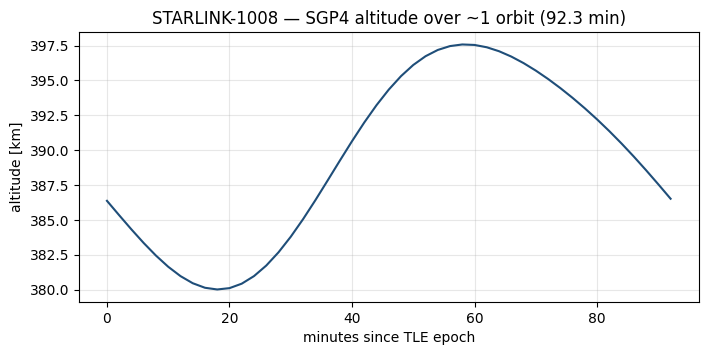

altitude range: 380.0 … 397.6 km


In [8]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not installed — skip plot, or: pip install matplotlib")
else:
    period_min = 1440.0 / (sat.no_kozai * 1440.0 / (2 * math.pi))
    minutes = list(range(0, int(period_min) + 1, 2))
    alts = []
    for m in minutes:
        err, r, _ = propagate_at(sat, epoch + timedelta(minutes=m))
        alts.append(float("nan") if err else mag(r) - EARTH_RADIUS_KM)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(minutes, alts, color="#1f4e79")
    ax.set_xlabel("minutes since TLE epoch")
    ax.set_ylabel("altitude [km]")
    ax.set_title(f"{name.strip()} — SGP4 altitude over ~1 orbit ({period_min:.1f} min)")
    ax.grid(True, alpha=0.3)
    plt.show()
    print(f"altitude range: {min(alts):.1f} … {max(alts):.1f} km")

## 6. Two lines: SGP4 propagation vs “actual” positions

True GPS/ephemeris for Starlink isn’t free, so the usual catalog proxy is:

- **Propagated** — take an *older* TLE and run SGP4 forward  
- **Actual (reference)** — take a *fresher* TLE for the same NORAD ID and evaluate it at the same times (near its own epoch this is much closer to “where the catalog thinks it is”)

Plot both altitudes, then the growing `|r_prop − r_ref|`. That drift is why conjunction pipelines keep refreshing TLEs.

In [ ]:
# Older TLE we already have locally (propagation start).
# Fresher TLE = live fetch for same name, else checked-in sample.
OLD_TLE_PATH = Path("data/starlink_1008.tle")
if not OLD_TLE_PATH.exists():
    OLD_TLE_PATH = Path("notebooks/data/starlink_1008.tle")

FRESH_LOCAL = Path("data/starlink_1008_fresh.tle")
if not FRESH_LOCAL.exists():
    FRESH_LOCAL = Path("notebooks/data/starlink_1008_fresh.tle")


def load_tle_file(path: Path) -> tuple[str, str, str]:
    return _parse_3le_block(path.read_text())


name_old, l1_old, l2_old = load_tle_file(OLD_TLE_PATH)
try:
    name_ref, l1_ref, l2_ref, ref_source = fetch_starlink_tle(TARGET_NAME)
except Exception as err:
    print(f"Live fresh TLE failed ({err!r}); using local fresh sample")
    name_ref, l1_ref, l2_ref = load_tle_file(FRESH_LOCAL)
    ref_source = f"local fresh sample ({FRESH_LOCAL})"

sat_prop = Satrec.twoline2rv(l1_old, l2_old)   # older → propagate
sat_ref = Satrec.twoline2rv(l1_ref, l2_ref)     # fresher → "actual"
epoch_prop = sat_epoch_datetime(sat_prop)
epoch_ref = sat_epoch_datetime(sat_ref)

print(f"propagated from: {name_old}  epoch {epoch_prop.isoformat()}")
print(f"  {l1_old}")
print(f"reference/actual: {name_ref}  epoch {epoch_ref.isoformat()}")
print(f"  source: {ref_source}")
print(f"  {l1_ref}")
print(f"epoch gap: {(epoch_ref - epoch_prop).total_seconds() / 3600:.2f} h")

# Common time grid: from older epoch through a bit past the fresher epoch
span_h = max(48.0, (epoch_ref - epoch_prop).total_seconds() / 3600.0 + 12.0)
step_min = 15
times, alt_prop, alt_ref, err_km = [], [], [], []

for m in range(0, int(span_h * 60) + 1, step_min):
    when = epoch_prop + timedelta(minutes=m)
    e1, r1, _ = propagate_at(sat_prop, when)
    e2, r2, _ = propagate_at(sat_ref, when)
    if e1 or e2:
        continue
    times.append(m / 60.0)
    alt_prop.append(mag(r1) - EARTH_RADIUS_KM)
    alt_ref.append(mag(r2) - EARTH_RADIUS_KM)
    err_km.append(mag((r1[0] - r2[0], r1[1] - r2[1], r1[2] - r2[2])))

# Snapshot at the fresher TLE's epoch (fairest "actual" comparison)
e1, r1, _ = propagate_at(sat_prop, epoch_ref)
e2, r2, _ = propagate_at(sat_ref, epoch_ref)
dr_at_ref = mag((r1[0] - r2[0], r1[1] - r2[1], r1[2] - r2[2])) if not (e1 or e2) else float("nan")
print(f"\nAt fresher TLE epoch ({epoch_ref.isoformat()}):")
print(f"  |r_prop − r_actual| = {dr_at_ref:.3f} km")
print(f"  (propagated from a TLE {(epoch_ref - epoch_prop).total_seconds()/3600:.1f} h older)")

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not installed — printed the error number above; install to see the two-line plot")
else:
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    ax0.plot(times, alt_prop, color="#1f4e79", label="SGP4 from older TLE (propagated)")
    ax0.plot(times, alt_ref, color="#c45c26", linestyle="--", label="Fresher TLE (actual / reference)")
    ax0.axvline((epoch_ref - epoch_prop).total_seconds() / 3600.0, color="gray", ls=":", lw=1, label="fresher TLE epoch")
    ax0.set_ylabel("altitude [km]")
    ax0.set_title(f"{TARGET_NAME}: propagated vs actual (fresher TLE proxy)")
    ax0.legend(loc="best", fontsize=8)
    ax0.grid(True, alpha=0.3)

    ax1.plot(times, err_km, color="#333333")
    ax1.axvline((epoch_ref - epoch_prop).total_seconds() / 3600.0, color="gray", ls=":", lw=1)
    ax1.set_xlabel("hours since older TLE epoch")
    ax1.set_ylabel("|Δr| [km]")
    ax1.set_title("Position difference grows with propagation age")
    ax1.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
    print(f"max |Δr| over window: {max(err_km):.3f} km")

## Stretch (Phase 5 preview)

Pull a second Starlink from the same shell/launch (another `NAME=` / `CATNR=` query), propagate both on the same time grid, and compute `|r1 − r2|` at each step. That's a tiny hand-rolled conjunction screen — the same geometry Phase 5 will do at scale.